# Linear Algebra Concepts

The central object is a linear map $A : \mathbb{R}^n \to \mathbb{R}^m$. The chapter moves from vector spaces to local linear models of nonlinear geometry.

## Concept Map

| Order | Section | Core notation | Role |
|---:|---|---|---|
| 1 | Subspace, span, basis, dimension | $W \le V$, $\operatorname{span}(v_1,\ldots,v_k)$, $\dim W$ | Builds coordinate systems for linear sets. |
| 2 | Linear maps and four fundamental subspaces | $\mathcal{C}(A)$, $\mathcal{N}(A)$, $\mathcal{C}(A^\top)$, $\mathcal{N}(A^\top)$ | Splits the domain and codomain of $A$. |
| 3 | Rank | $\operatorname{rank}(A)=\dim \mathcal{C}(A)$ | Measures the dimension preserved by $A$. |
| 4 | Null space | $\mathcal{N}(A)=\{x:Ax=0\}$ | Measures directions collapsed by $A$. |
| 5 | Orthogonality and projection | $\langle u,v\rangle=0$, $P=QQ^\top$ | Gives closest points and least-squares geometry. |
| 6 | Normal spaces | $N_pM=(T_pM)^\perp$ | Describes directions perpendicular to a tangent space. |
| 7 | Inverse and pseudoinverse | $A^{-1}$, $A^+$ | Solves exact, least-squares, and minimum-norm systems. |
| 8 | Eigenvectors and SVD | $Av=\lambda v$, $A=U\Sigma V^\top$ | Exposes invariant directions, stretch, rank, and conditioning. |
| 9 | Conditioning | $\kappa_2(A)=\sigma_{\max}/\sigma_{\min}$ | Quantifies sensitivity to perturbations. |
| 10 | Jacobian and manifold | $J_f(p)$, $T_pM$ | Extends linear algebra to local nonlinear geometry. |

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

sns.set_theme(context='talk', style='ticks', palette='dark')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams["savefig.transparent"] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['figure.figsize'] = [3.0, 3.0]
plt.rcParams['patch.linewidth'] = 0
rcParams['image.interpolation'] = 'none'
plt.rcParams.update({
    "legend.frameon": False,
    "legend.loc": "lower right",
})

np.set_printoptions(precision=3, suppress=True)


def draw_vector(ax, vector, origin=(0, 0), color="C0", label=None, width=0.02):
    origin = np.asarray(origin, dtype=float)
    vector = np.asarray(vector, dtype=float)
    ax.arrow(
        origin[0], origin[1], vector[0], vector[1],
        head_width=0.10,
        length_includes_head=True,
        color=color,
        linewidth=2,
        width=width,
    )
    if label:
        tip = origin + vector
        ax.text(tip[0] + 0.06, tip[1] + 0.06, label, color=color, fontsize=12)


def label_box(ax, text, xy=(0.05, 0.95), ha="left", va="top"):
    ax.text(
        xy[0], xy[1], text,
        transform=ax.transAxes,
        ha=ha,
        va=va,
        fontsize=12,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none", "pad": 4},
    )


def set_equal_axes(ax, xlim=(-3, 3), ylim=(-3, 3)):
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)


def finish_figure(fig):
    sns.despine(fig=fig, trim=True, offset=10)
    fig.tight_layout()


def matrix_rank(A, tol=1e-10):
    return int(np.sum(np.linalg.svd(A, compute_uv=False) > tol))


def null_space(A, tol=1e-10):
    _, singular_values, vh = np.linalg.svd(A)
    rank = np.sum(singular_values > tol)
    return vh[rank:].T


def column_space(A, tol=1e-10):
    u, singular_values, _ = np.linalg.svd(A, full_matrices=False)
    rank = np.sum(singular_values > tol)
    return u[:, :rank]


def orient(vector):
    vector = np.asarray(vector, dtype=float).copy()
    first_nonzero = np.flatnonzero(np.abs(vector) > 1e-12)
    if first_nonzero.size and vector[first_nonzero[0]] < 0:
        vector *= -1
    return vector


def orthonormalize(columns):
    q, _ = np.linalg.qr(np.asarray(columns, dtype=float))
    return q

## Subspace, Span, Basis, Dimension

Let $V$ be a vector space over a field $\mathbb{F}$. A subset $W\subseteq V$ is a **linear subspace** if it is nonempty and closed under linear combinations:

$$
u,v\in W,\ a,b\in\mathbb{F}\quad\Longrightarrow\quad au+bv\in W.
$$

Equivalently, $W$ is a vector space using the addition and scalar multiplication inherited from $V$.

The **span** of vectors $v_1,\ldots,v_k$ is

$$
\operatorname{span}(v_1,\ldots,v_k)=\left\{\sum_{i=1}^{k} a_i v_i : a_i\in\mathbb{F}\right\}.
$$

A list is **linearly independent** if no vector in it is a linear combination of the others. A **basis** for $W$ is a linearly independent spanning list. The **dimension** $\dim W$ is the number of vectors in any basis for $W$.

A line through the origin is a linear subspace of $\mathbb{R}^2$. A shifted line is affine, not linear, because it does not contain $0$.

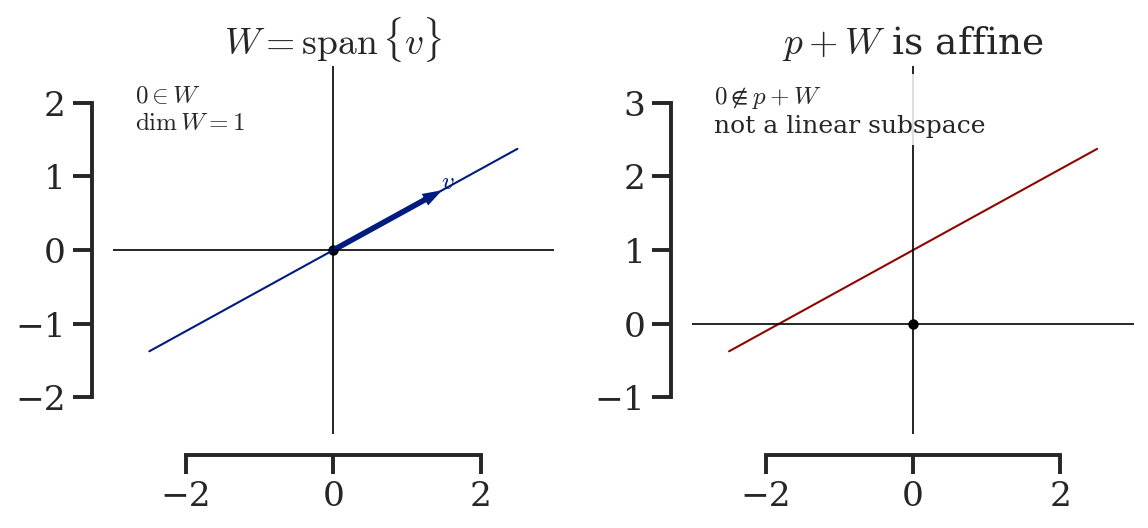

In [48]:
t = np.linspace(-2.5, 2.5, 200)
linear_subspace = np.vstack([t, 0.55 * t])
affine_line = linear_subspace + np.array([[0.0], [1.0]])
basis_for_line = np.array([[1.0], [0.55]])

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))

axes[0].plot(linear_subspace[0], linear_subspace[1], color="C0")
axes[0].scatter([0], [0], color="black", s=25)
draw_vector(axes[0], [1.4, 0.77], color="C0", label=r"$v$")
set_equal_axes(axes[0], (-3, 3), (-2.5, 2.5))
axes[0].set_title(r"$W=\operatorname{span}\{v\}$")
label_box(axes[0], rf"$0\in W$" + "\n" + rf"$\dim W={matrix_rank(basis_for_line)}$")

axes[1].plot(affine_line[0], affine_line[1], color="C3")
axes[1].scatter([0], [0], color="black", s=25)
set_equal_axes(axes[1], (-3, 3), (-1.5, 3.5))
axes[1].set_title(r"$p+W$ is affine")
label_box(axes[1], r"$0\notin p+W$" + "\n" + r"not a linear subspace")

finish_figure(fig)
plt.show()

## Linear Maps and the Four Fundamental Subspaces

A matrix $A\in\mathbb{R}^{m\times n}$ represents a linear map

$$
A:\mathbb{R}^n\to\mathbb{R}^m,\qquad x\mapsto Ax.
$$

The four fundamental subspaces are

| Subspace | Notation | Ambient space |
|---|---|---|
| Column space / image | $\mathcal{C}(A)=\{Ax:x\in\mathbb{R}^n\}$ | $\mathbb{R}^m$ |
| Null space / kernel | $\mathcal{N}(A)=\{x\in\mathbb{R}^n:Ax=0\}$ | $\mathbb{R}^n$ |
| Row space | $\mathcal{C}(A^\top)$ | $\mathbb{R}^n$ |
| Left null space | $\mathcal{N}(A^\top)$ | $\mathbb{R}^m$ |

For real matrices,

$$
\mathcal{C}(A^\top)=\mathcal{N}(A)^\perp,\qquad
\mathcal{C}(A)=\mathcal{N}(A^\top)^\perp.
$$

If $A$ has $n$ columns, the rank-nullity theorem is

$$
\operatorname{rank}(A)+\dim\mathcal{N}(A)=n.
$$

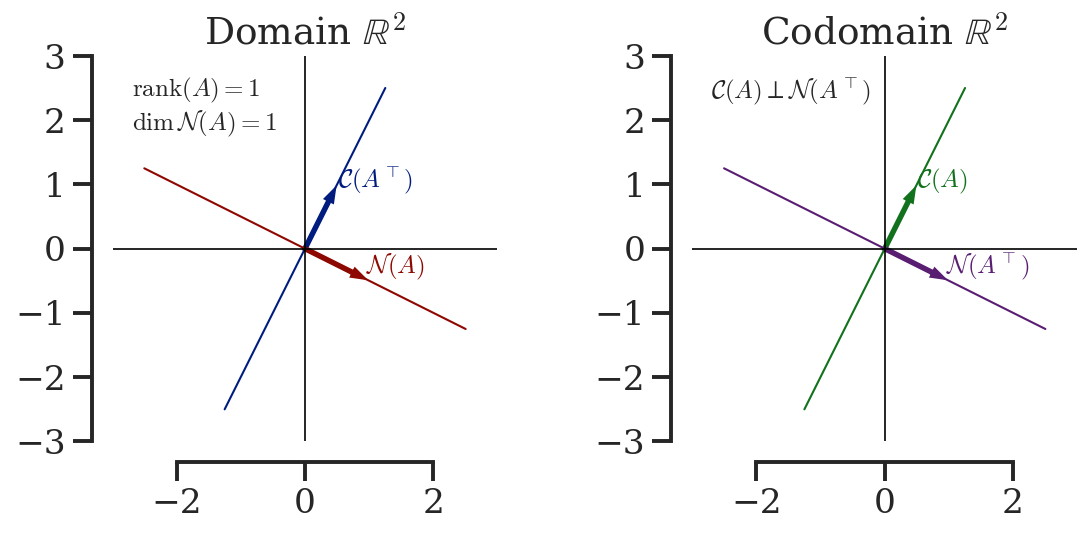

In [49]:
A = np.array([[1.0, 2.0], [2.0, 4.0]])
rank_A = matrix_rank(A)
row_direction = orient(column_space(A.T)[:, 0])
null_direction = orient(null_space(A)[:, 0])
column_direction = orient(column_space(A)[:, 0])
left_null_direction = orient(null_space(A.T)[:, 0])

s = np.linspace(-2.8, 2.8, 200)
row_line = row_direction[:, None] * s
null_line = null_direction[:, None] * s
column_line = column_direction[:, None] * s
left_null_line = left_null_direction[:, None] * s

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

axes[0].plot(row_line[0], row_line[1], color="C0")
axes[0].plot(null_line[0], null_line[1], color="C3")
draw_vector(axes[0], row_direction, color="C0", label=r"$\mathcal{C}(A^\top)$")
draw_vector(axes[0], null_direction, color="C3", label=r"$\mathcal{N}(A)$")
set_equal_axes(axes[0], (-3, 3), (-3, 3))
axes[0].set_title(r"Domain $\mathbb{R}^2$")
label_box(axes[0], rf"$\operatorname{{rank}}(A)={rank_A}$" + "\n" + rf"$\dim\mathcal{{N}}(A)={null_space(A).shape[1]}$")

axes[1].plot(column_line[0], column_line[1], color="C2")
axes[1].plot(left_null_line[0], left_null_line[1], color="C4")
draw_vector(axes[1], column_direction, color="C2", label=r"$\mathcal{C}(A)$")
draw_vector(axes[1], left_null_direction, color="C4", label=r"$\mathcal{N}(A^\top)$")
set_equal_axes(axes[1], (-3, 3), (-3, 3))
axes[1].set_title(r"Codomain $\mathbb{R}^2$")
label_box(axes[1], r"$\mathcal{C}(A)\perp\mathcal{N}(A^\top)$")

finish_figure(fig)
plt.show()

## Rank

For $A\in\mathbb{R}^{m\times n}$, the **rank** is the dimension of the image:

$$
\operatorname{rank}(A)=\dim\mathcal{C}(A).
$$

Equivalent characterizations are

$$
\operatorname{rank}(A)=\dim\mathcal{C}(A^\top)=\#\{\text{nonzero singular values of }A\}.
$$

The bounds are

$$
0\le \operatorname{rank}(A)\le \min(m,n).
$$

A matrix is **full rank** if its rank is the largest value allowed by its shape. Otherwise it is rank deficient.

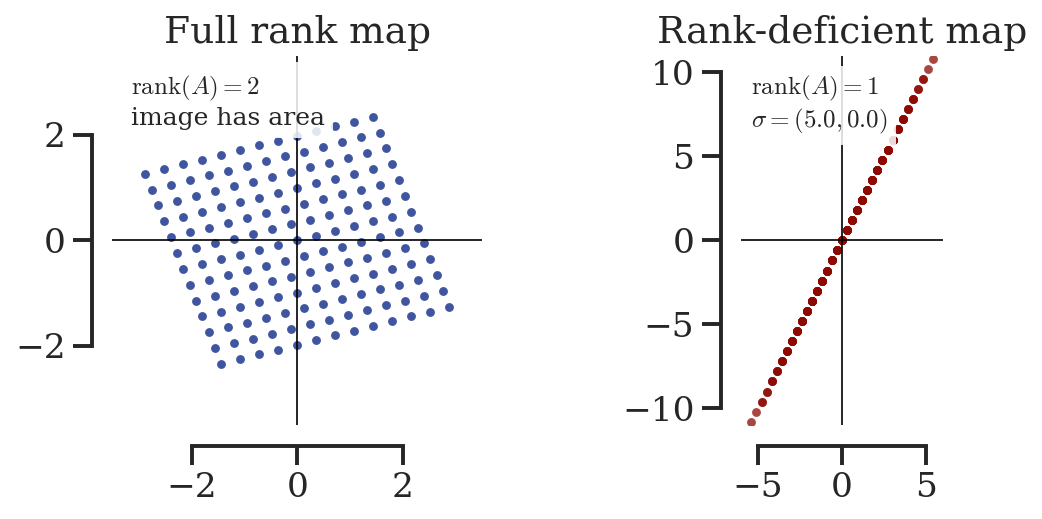

In [50]:
grid_values = np.linspace(-1.8, 1.8, 13)
base_points = np.array([(x, y) for x in grid_values for y in grid_values])

rank_two_matrix = np.array([[1.2, -0.4], [0.3, 1.0]])
rank_one_matrix = np.array([[1.0, 2.0], [2.0, 4.0]])

rank_two_points = base_points @ rank_two_matrix.T
rank_one_points = base_points @ rank_one_matrix.T
singular_values_rank_one = np.linalg.svd(rank_one_matrix, compute_uv=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

axes[0].scatter(rank_two_points[:, 0], rank_two_points[:, 1], color="C0", s=18, alpha=0.75)
set_equal_axes(axes[0], (-3.5, 3.5), (-3.5, 3.5))
axes[0].set_title(r"Full rank map")
label_box(axes[0], rf"$\operatorname{{rank}}(A)={matrix_rank(rank_two_matrix)}$" + "\n" + r"image has area")

axes[1].scatter(rank_one_points[:, 0], rank_one_points[:, 1], color="C3", s=18, alpha=0.75)
set_equal_axes(axes[1], (-6, 6), (-11, 11))
axes[1].set_title(r"Rank-deficient map")
label_box(
    axes[1],
    rf"$\operatorname{{rank}}(A)={matrix_rank(rank_one_matrix)}$" + "\n" +
    rf"$\sigma=({singular_values_rank_one[0]:.1f},{singular_values_rank_one[1]:.1f})$",
)

finish_figure(fig)
plt.show()

## Null Space

For $A\in\mathbb{R}^{m\times n}$, the **null space** or **kernel** is

$$
\mathcal{N}(A)=\ker(A)=\{x\in\mathbb{R}^n:Ax=0\}.
$$

It is a subspace of the domain $\mathbb{R}^n$. Its dimension is the **nullity**:

$$
\operatorname{nullity}(A)=\dim\mathcal{N}(A).
$$

If $x_0$ is one solution of $Ax=b$, then every solution has the form

$$
x=x_0+z,\qquad z\in\mathcal{N}(A).
$$

Thus $\mathcal{N}(A)$ describes the directions along which a linear system is nonunique.

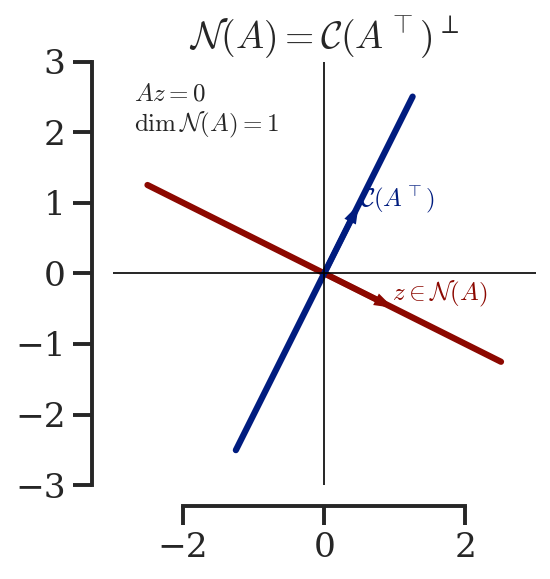

In [51]:
A = np.array([[1.0, 2.0], [2.0, 4.0]])
N = null_space(A)
null_direction = orient(N[:, 0])
row_direction = orient(A[0] / np.linalg.norm(A[0]))

s = np.linspace(-2.8, 2.8, 200)
null_line = null_direction[:, None] * s
row_line = row_direction[:, None] * s

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot(null_line[0], null_line[1], color="C3", linewidth=3)
ax.plot(row_line[0], row_line[1], color="C0", linewidth=3)
draw_vector(ax, null_direction, color="C3", label=r"$z\in\mathcal{N}(A)$")
draw_vector(ax, row_direction, color="C0", label=r"$\mathcal{C}(A^\top)$")
set_equal_axes(ax, (-3, 3), (-3, 3))
ax.set_title(r"$\mathcal{N}(A)=\mathcal{C}(A^\top)^\perp$")
label_box(ax, r"$Az=0$" + "\n" + rf"$\dim\mathcal{{N}}(A)={N.shape[1]}$")
finish_figure(fig)
plt.show()

## Orthogonal, Orthonormal, Projection

In an inner-product space, vectors $u$ and $v$ are **orthogonal** if

$$
\langle u,v\rangle=0.
$$

For real coordinate vectors, $\langle u,v\rangle=u^\top v$.

A list $q_1,\ldots,q_k$ is **orthonormal** if

$$
\langle q_i,q_j\rangle=\delta_{ij}.
$$

If $Q=[q_1\ \cdots\ q_k]$, this condition is

$$
Q^\top Q=I_k.
$$

The orthogonal projection of $x$ onto $\mathcal{C}(Q)$ is

$$
\operatorname{proj}_{\mathcal{C}(Q)}(x)=QQ^\top x.
$$

The residual $r=x-QQ^\top x$ satisfies $Q^\top r=0$.

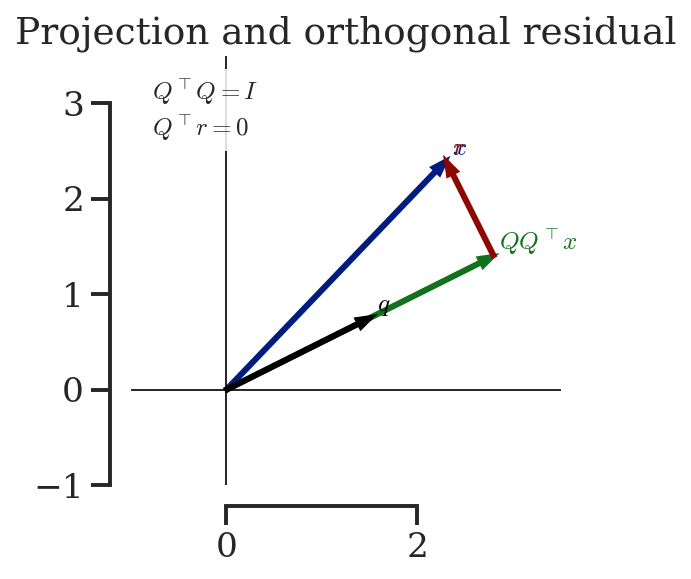

In [52]:
basis = np.array([[2.0], [1.0]])
Q = orthonormalize(basis)
if Q[0, 0] < 0:
    Q[:, 0] *= -1
q = Q[:, 0]

x = np.array([2.3, 2.4])
projection = Q @ (Q.T @ x)
residual = x - projection

fig, ax = plt.subplots(figsize=(4.2, 4.2))
set_equal_axes(ax, (-1, 3.5), (-1, 3.5))
draw_vector(ax, x, color="C0", label=r"$x$")
draw_vector(ax, projection, color="C2", label=r"$QQ^\top x$")
draw_vector(ax, residual, origin=projection, color="C3", label=r"$r$")
draw_vector(ax, 1.7 * q, color="black", label=r"$q$")
ax.plot([x[0], projection[0]], [x[1], projection[1]], color="C3", linestyle="--")
ax.set_title(r"Projection and orthogonal residual")
label_box(ax, r"$Q^\top Q=I$" + "\n" + r"$Q^\top r=0$")
finish_figure(fig)
plt.show()

## Normal Vectors and Normal Spaces

A **normal vector** is perpendicular to a tangent line, tangent plane, or tangent space at a point.

For a plane in $\mathbb{R}^3$,

$$
ax+by+cz=d,
$$

the vector $(a,b,c)$ is normal to the plane.

For an implicit surface

$$
F(x,y,z)=0,
$$

if $\nabla F(p)\ne 0$, then $\nabla F(p)$ is normal to the surface at $p$.

For a smooth embedded manifold $M\subseteq\mathbb{R}^n$, the **normal space** at $p$ is

$$
N_pM=(T_pM)^\perp.
$$

The matrix term **normal** is different: a real square matrix is normal if $A^\top A=AA^\top$.

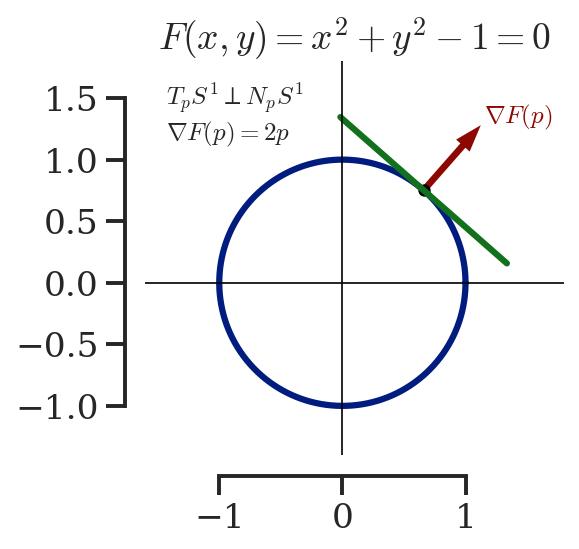

In [53]:
theta = 0.85
circle = np.column_stack([
    np.cos(np.linspace(0, 2 * np.pi, 300)),
    np.sin(np.linspace(0, 2 * np.pi, 300)),
])
point = np.array([np.cos(theta), np.sin(theta)])
tangent = np.array([-np.sin(theta), np.cos(theta)])
normal = point
s = np.linspace(-0.9, 0.9, 50)
tangent_line = point + s[:, None] * tangent

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot(circle[:, 0], circle[:, 1], color="C0", linewidth=3)
ax.plot(tangent_line[:, 0], tangent_line[:, 1], color="C2", linewidth=3)
draw_vector(ax, 0.65 * normal, origin=point, color="C3", label=r"$\nabla F(p)$")
ax.scatter([point[0]], [point[1]], color="black", s=35)
set_equal_axes(ax, (-1.6, 1.8), (-1.4, 1.8))
ax.set_title(r"$F(x,y)=x^2+y^2-1=0$")
label_box(ax, r"$T_pS^1\perp N_pS^1$" + "\n" + r"$\nabla F(p)=2p$")
finish_figure(fig)
plt.show()

## Inverse

A square matrix $A\in\mathbb{R}^{n\times n}$ is **invertible** if there exists $A^{-1}$ such that

$$
A^{-1}A=AA^{-1}=I_n.
$$

Equivalent tests are

$$
\operatorname{rank}(A)=n,
\qquad
\mathcal{N}(A)=\{0\},
\qquad
\det(A)\ne 0,
\qquad
\sigma_i(A)>0\ \text{for all }i.
$$

An inverse is a two-sided undoing map. Numerically, solve $Ax=b$ with a linear solver rather than explicitly forming $A^{-1}b$.

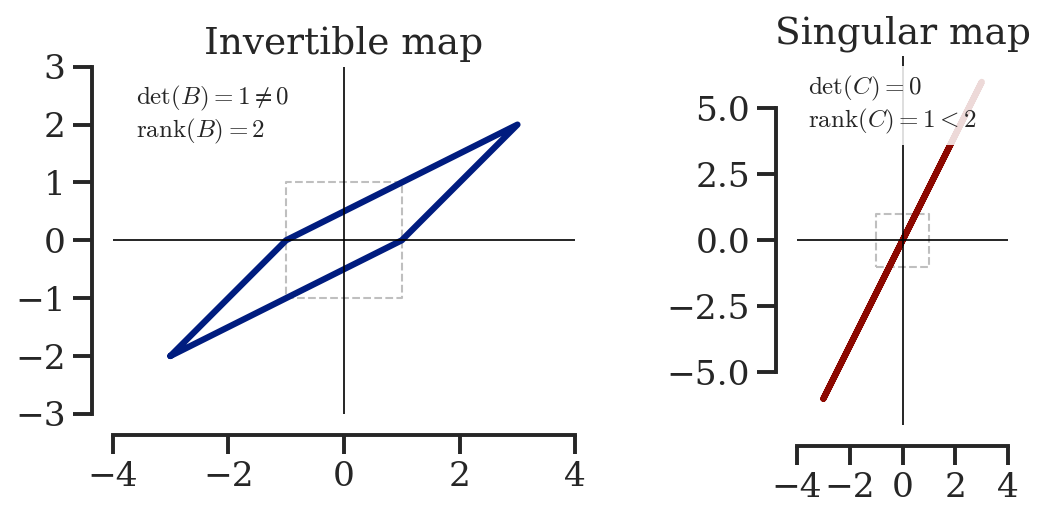

In [54]:
B = np.array([[2.0, 1.0], [1.0, 1.0]])
C = np.array([[1.0, 2.0], [2.0, 4.0]])

square = np.array([
    [-1.0, -1.0],
    [1.0, -1.0],
    [1.0, 1.0],
    [-1.0, 1.0],
    [-1.0, -1.0],
])
B_square = square @ B.T
C_square = square @ C.T

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

axes[0].plot(square[:, 0], square[:, 1], color="0.75", linestyle="--")
axes[0].plot(B_square[:, 0], B_square[:, 1], color="C0", linewidth=3)
set_equal_axes(axes[0], (-4, 4), (-3, 3))
axes[0].set_title(r"Invertible map")
label_box(
    axes[0],
    rf"$\det(B)={np.linalg.det(B):.0f}\ne0$" + "\n" +
    rf"$\operatorname{{rank}}(B)={matrix_rank(B)}$",
)

axes[1].plot(square[:, 0], square[:, 1], color="0.75", linestyle="--")
axes[1].plot(C_square[:, 0], C_square[:, 1], color="C3", linewidth=3)
set_equal_axes(axes[1], (-4, 4), (-7, 7))
axes[1].set_title(r"Singular map")
label_box(
    axes[1],
    rf"$\det(C)={np.linalg.det(C):.0f}$" + "\n" +
    rf"$\operatorname{{rank}}(C)={matrix_rank(C)}<2$",
)

finish_figure(fig)
plt.show()

## Moore-Penrose Pseudoinverse

For any real matrix $A$, the **Moore-Penrose pseudoinverse** $A^+$ is the unique matrix satisfying

$$
AA^+A=A,
\qquad
A^+AA^+=A^+,
\qquad
(AA^+)^\top=AA^+,
\qquad
(A^+A)^\top=A^+A.
$$

If $A=U\Sigma V^\top$ is an SVD, then

$$
A^+=V\Sigma^+U^\top,
$$

where $\Sigma^+$ transposes $\Sigma$ and replaces each nonzero singular value $\sigma_i$ by $1/\sigma_i$.

For $Ax=b$, the vector $A^+b$ is the least-squares solution when no exact solution exists, the minimum-norm exact solution when infinitely many exact solutions exist, and the ordinary inverse solution when $A$ is square and invertible.

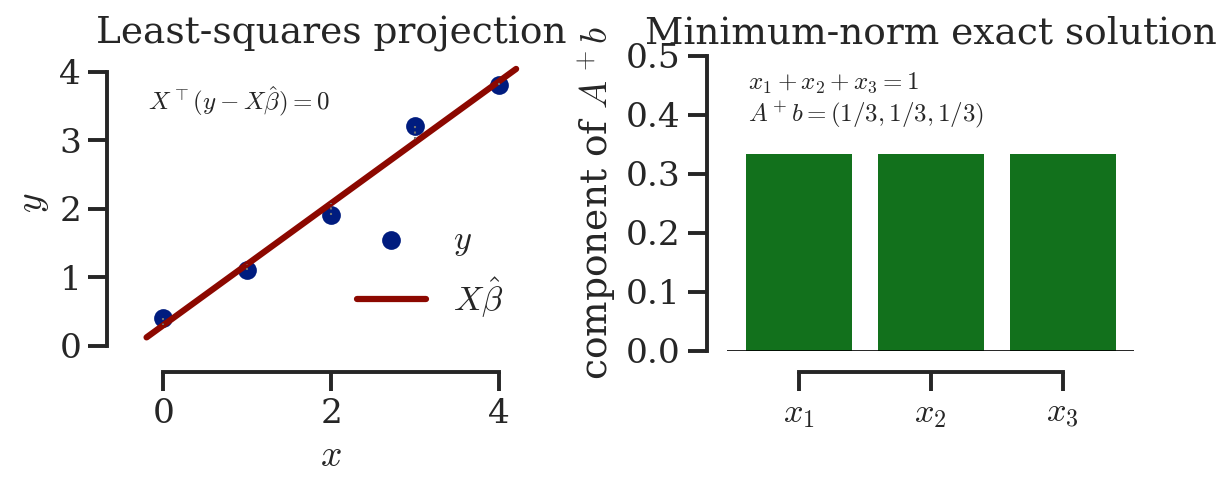

In [55]:
x_data = np.array([0, 1, 2, 3, 4], dtype=float)
y_data = np.array([0.4, 1.1, 1.9, 3.2, 3.8])
X = np.column_stack([x_data, np.ones_like(x_data)])

slope, intercept = np.linalg.pinv(X) @ y_data
fitted = X @ np.array([slope, intercept])
residual = y_data - fitted

underdetermined_A = np.array([[1.0, 1.0, 1.0]])
underdetermined_b = np.array([1.0])
minimum_norm_solution = np.linalg.pinv(underdetermined_A) @ underdetermined_b

x_line = np.linspace(-0.2, 4.2, 100)
y_line = slope * x_line + intercept

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))

axes[0].scatter(x_data, y_data, color="C0", label=r"$y$")
axes[0].plot(x_line, y_line, color="C3", linewidth=3, label=r"$X\hat\beta$")
for xi, yi, yhat in zip(x_data, y_data, fitted):
    axes[0].plot([xi, xi], [yi, yhat], color="0.45", linestyle=":", linewidth=1)
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].set_title(r"Least-squares projection")
label_box(axes[0], r"$X^\top(y-X\hat\beta)=0$", xy=(0.05, 0.9))
axes[0].legend()

axes[1].bar([r"$x_1$", r"$x_2$", r"$x_3$"], minimum_norm_solution, color="C2")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylim(0, 0.5)
axes[1].set_title(r"Minimum-norm exact solution")
axes[1].set_ylabel(r"component of $A^+b$")
label_box(axes[1], r"$x_1+x_2+x_3=1$" + "\n" + r"$A^+b=(1/3,1/3,1/3)$")

finish_figure(fig)
plt.show()

## Eigenvalues and Eigenvectors

For a square matrix $A\in\mathbb{R}^{n\times n}$, a nonzero vector $v$ is an **eigenvector** with **eigenvalue** $\lambda$ if

$$
Av=\lambda v.
$$

The direction of $v$ is preserved by the linear map; only its scale changes. Eigenvectors are defined for maps from a vector space to itself.

For a real symmetric matrix, the spectral theorem gives an orthonormal eigenbasis:

$$
A=Q\Lambda Q^\top,
\qquad
Q^\top Q=I.
$$

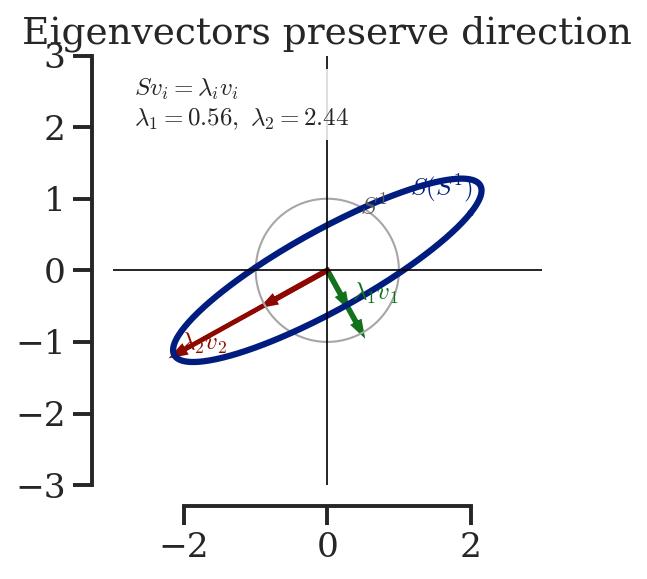

In [56]:
S = np.array([[2.0, 0.8], [0.8, 1.0]])
eigenvalues, eigenvectors = np.linalg.eigh(S)

circle_angles = np.linspace(0, 2 * np.pi, 300)
unit_circle = np.column_stack([np.cos(circle_angles), np.sin(circle_angles)])
image = unit_circle @ S.T

fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.plot(unit_circle[:, 0], unit_circle[:, 1], color="0.65")
ax.plot(image[:, 0], image[:, 1], color="C0", linewidth=3)
ax.text(0.45, 0.78, r"$S^1$", color="0.35", fontsize=12)
ax.text(1.15, 1.05, r"$S(S^1)$", color="C0", fontsize=12)

for i, value in enumerate(eigenvalues):
    vector = eigenvectors[:, i]
    color = f"C{i+2}"
    draw_vector(ax, vector, color=color)
    draw_vector(ax, value * vector, color=color, width=0.01)
    endpoint = value * vector
    ax.text(endpoint[0] + 0.08, endpoint[1] + 0.08, rf"$\lambda_{i+1}v_{i+1}$", color=color, fontsize=12)

set_equal_axes(ax, (-3, 3), (-3, 3))
ax.set_title(r"Eigenvectors preserve direction")
label_box(ax, rf"$Sv_i=\lambda_i v_i$" + "\n" + rf"$\lambda_1={eigenvalues[0]:.2f},\ \lambda_2={eigenvalues[1]:.2f}$")
finish_figure(fig)
plt.show()

## Singular Value Decomposition

Every real matrix $A\in\mathbb{R}^{m\times n}$ has a **singular value decomposition**

$$
A=U\Sigma V^\top,
$$

where the columns of $U$ and $V$ are orthonormal and $\Sigma$ is diagonal apart from possible extra zero rows or columns.

The singular values describe how $A$ stretches orthogonal input directions:

$$
Av_i=\sigma_i u_i.
$$

The SVD exposes rank, null space, column space, conditioning, and the pseudoinverse. The rank is the number of nonzero singular values.

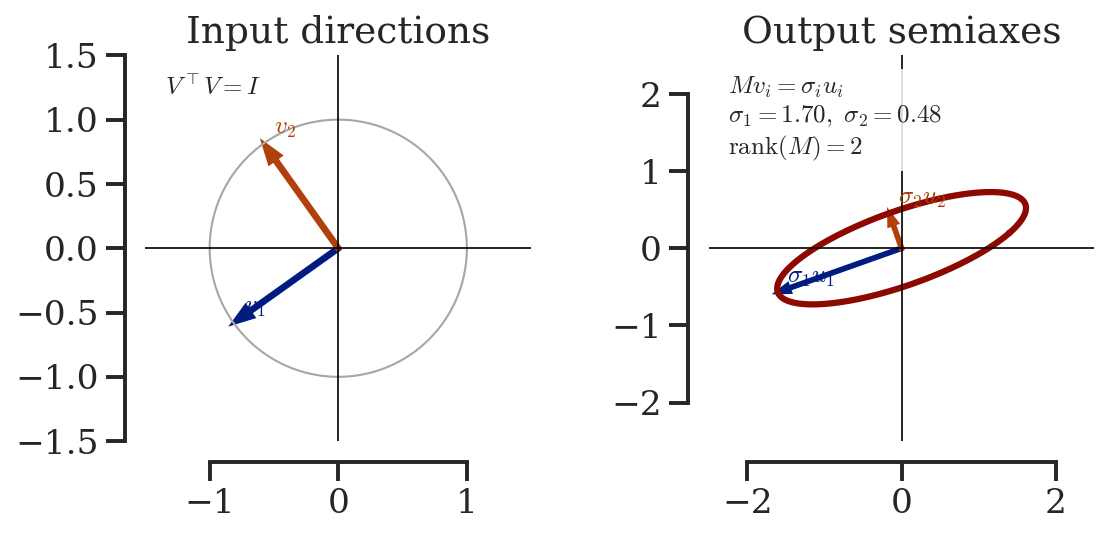

In [57]:
M = np.array([[1.4, 0.8], [0.2, 0.7]])
U, singular_values, Vt = np.linalg.svd(M)
V = Vt.T
rank_M = matrix_rank(M)

circle_angles = np.linspace(0, 2 * np.pi, 300)
unit_circle = np.column_stack([np.cos(circle_angles), np.sin(circle_angles)])
image = unit_circle @ M.T

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

axes[0].plot(unit_circle[:, 0], unit_circle[:, 1], color="0.65")
for i in range(2):
    draw_vector(axes[0], V[:, i], color=f"C{i}")
    tip = V[:, i]
    axes[0].text(tip[0] + 0.08, tip[1] + 0.08, rf"$v_{i+1}$", color=f"C{i}", fontsize=12)
set_equal_axes(axes[0], (-1.5, 1.5), (-1.5, 1.5))
axes[0].set_title(r"Input directions")
label_box(axes[0], r"$V^\top V=I$")

axes[1].plot(image[:, 0], image[:, 1], color="C3", linewidth=3)
for i in range(2):
    output_vector = singular_values[i] * U[:, i]
    draw_vector(axes[1], output_vector, color=f"C{i}")
    axes[1].text(
        output_vector[0] + 0.12,
        output_vector[1] + 0.12,
        rf"$\sigma_{i+1}u_{i+1}$",
        color=f"C{i}",
        fontsize=12,
    )
set_equal_axes(axes[1], (-2.5, 2.5), (-2.5, 2.5))
axes[1].set_title(r"Output semiaxes")
label_box(
    axes[1],
    rf"$Mv_i=\sigma_i u_i$" + "\n" +
    rf"$\sigma_1={singular_values[0]:.2f},\ \sigma_2={singular_values[1]:.2f}$" + "\n" +
    rf"$\operatorname{{rank}}(M)={rank_M}$",
)

finish_figure(fig)
plt.show()

## Conditioning

The **condition number** measures sensitivity to small input changes. For a full-rank square matrix in the Euclidean norm,

$$
\kappa_2(A)=\|A\|_2\|A^{-1}\|_2=\frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}.
$$

A large $\kappa_2(A)$ means that solving $Ax=b$ can amplify small perturbations in $b$ or small errors in $A$.

Rank and conditioning are related but not identical: a matrix can be full rank and still be nearly singular if $\sigma_{\min}(A)$ is very small.

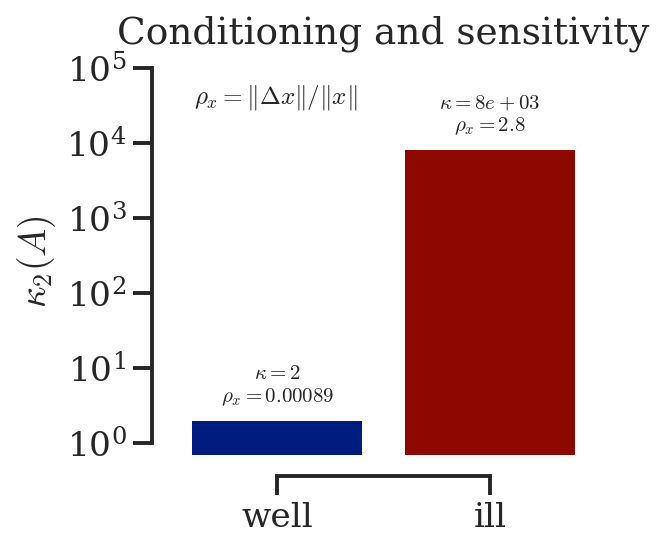

In [58]:
well_conditioned = np.array([[2.0, 0.0], [0.0, 1.0]])
ill_conditioned = np.array([[1.0, 1.0], [1.0, 1.0005]])
b = np.array([1.0, 1.0])
delta_b = np.array([0.0, 0.001])

matrices = [well_conditioned, ill_conditioned]
labels = [r"well", r"ill"]
condition_numbers = []
relative_solution_changes = []

for A in matrices:
    x = np.linalg.solve(A, b)
    x_perturbed = np.linalg.solve(A, b + delta_b)
    condition_numbers.append(np.linalg.cond(A))
    relative_solution_changes.append(np.linalg.norm(x_perturbed - x) / np.linalg.norm(x))

fig, ax = plt.subplots(figsize=(4.4, 4.0))
bars = ax.bar(labels, condition_numbers, color=["C0", "C3"])
ax.set_yscale("log")
ax.set_ylim(0.7, 1e5)
ax.set_ylabel(r"$\kappa_2(A)$")
ax.set_title(r"Conditioning and sensitivity", pad=12)
label_box(ax, r"$\rho_x=\|\Delta x\|/\|x\|$", xy=(0.05, 0.96))
for bar, condition_number, relative_change in zip(bars, condition_numbers, relative_solution_changes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        condition_number * 1.5,
        rf"$\kappa={condition_number:.1g}$" + "\n" + rf"$\rho_x={relative_change:.2g}$",
        ha="center",
        va="bottom",
        fontsize=10,
    )
finish_figure(fig)
plt.show()

## Jacobian

For a differentiable map

$$
f:\mathbb{R}^n\to\mathbb{R}^m,
\qquad
f(x)=\bigl(f_1(x),\ldots,f_m(x)\bigr),
$$

the **Jacobian matrix** at $x$ is

$$
J_f(x)=\left[\frac{\partial f_i}{\partial x_j}(x)\right]_{i=1,\ldots,m}^{j=1,\ldots,n}\in\mathbb{R}^{m\times n}.
$$

The Jacobian is the derivative represented as a linear map:

$$
f(p+h)=f(p)+J_f(p)h+o(\|h\|).
$$

If $m=n$, $\det J_f(p)$ is the local volume scale and orientation sign. A zero determinant signals failure of local invertibility for square maps.

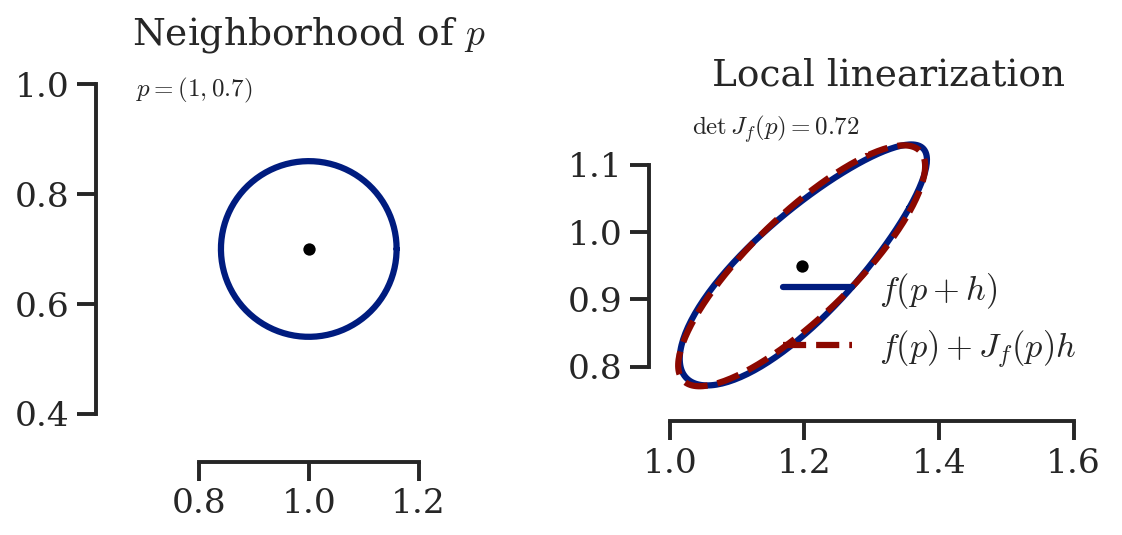

In [59]:
def f(points):
    x = points[:, 0]
    y = points[:, 1]
    return np.column_stack([x + 0.4 * y**2, y + 0.25 * x**2])


def jacobian_at(point):
    x, y = point
    return np.array([[1.0, 0.8 * y], [0.5 * x, 1.0]])


p = np.array([1.0, 0.7])
J = jacobian_at(p)
f_p = f(p[None, :])[0]

angles = np.linspace(0, 2 * np.pi, 200)
small_circle = p + 0.16 * np.column_stack([np.cos(angles), np.sin(angles)])
nonlinear_image = f(small_circle)
linear_image = f_p + (small_circle - p) @ J.T

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

axes[0].plot(small_circle[:, 0], small_circle[:, 1], color="C0", linewidth=3)
axes[0].scatter([p[0]], [p[1]], color="black", s=35)
set_equal_axes(axes[0], (0.65, 1.35), (0.35, 1.05))
axes[0].set_title(r"Neighborhood of $p$")
label_box(axes[0], r"$p=(1,0.7)$")

axes[1].plot(nonlinear_image[:, 0], nonlinear_image[:, 1], color="C0", linewidth=3, label=r"$f(p+h)$")
axes[1].plot(linear_image[:, 0], linear_image[:, 1], color="C3", linestyle="--", linewidth=3, label=r"$f(p)+J_f(p)h$")
axes[1].scatter([f_p[0]], [f_p[1]], color="black", s=35)
set_equal_axes(axes[1], (1.0, 1.65), (0.75, 1.2))
axes[1].set_title(r"Local linearization")
label_box(axes[1], rf"$\det J_f(p)={np.linalg.det(J):.2f}$")
axes[1].legend()

finish_figure(fig)
plt.show()

## Manifold

An $n$-dimensional **topological manifold** is a Hausdorff, second-countable topological space $M$ such that every point $p\in M$ has a neighborhood homeomorphic to an open subset of $\mathbb{R}^n$.

A **chart** is such a local coordinate map. An **atlas** is a compatible collection of charts covering $M$.

A **smooth manifold** adds smooth compatibility of overlapping charts, so calculus is independent of the chosen coordinates.

Important distinctions:

- A manifold is not merely a curved subset; $\mathbb{R}^n$ is itself a manifold.
- The definition is local. The circle $S^1$ is not globally an interval, but each small arc is locally like an open interval.
- Singular points break the manifold property. A figure-eight curve is not a $1$-manifold at its crossing.
- Tangent spaces require differentiable structure. Normal spaces require an embedding or a metric/inner-product structure.

For the unit circle $S^1=\{(x,y)\in\mathbb{R}^2:x^2+y^2=1\}$, one chart on the upper semicircle is

$$
\chi(x,y)=x,
\qquad
\chi^{-1}(a)=\bigl(a,\sqrt{1-a^2}\bigr),
\qquad
-1<a<1.
$$

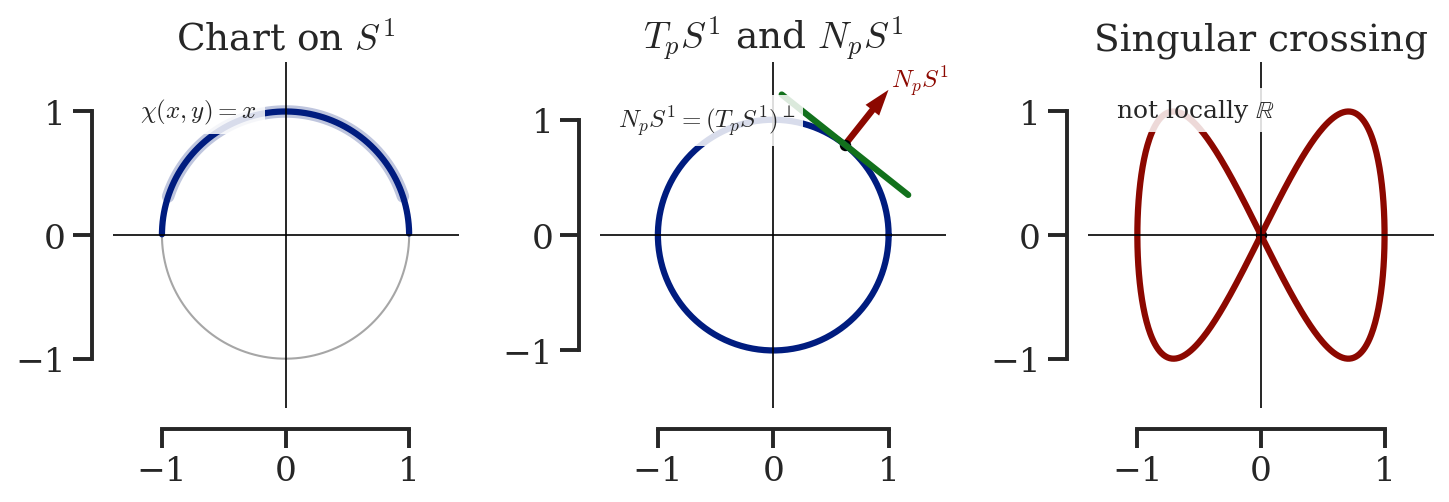

In [60]:
theta = np.linspace(0, 2 * np.pi, 500)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
upper = circle[circle[:, 1] > 0]
figure_eight = np.column_stack([np.sin(theta), np.sin(2 * theta)])

p = np.array([np.cos(0.9), np.sin(0.9)])
tangent = np.array([-np.sin(0.9), np.cos(0.9)])
normal = p
s = np.linspace(-0.7, 0.7, 80)
tangent_line = p + s[:, None] * tangent

chart_x = np.linspace(-0.95, 0.95, 200)
chart_y = np.sqrt(1 - chart_x**2)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].plot(circle[:, 0], circle[:, 1], color="0.65")
axes[0].plot(upper[:, 0], upper[:, 1], color="C0", linewidth=3)
axes[0].plot(chart_x, chart_y, color="C0", alpha=0.25, linewidth=6)
set_equal_axes(axes[0], (-1.4, 1.4), (-1.4, 1.4))
axes[0].set_title(r"Chart on $S^1$")
label_box(axes[0], r"$\chi(x,y)=x$", xy=(0.08, 0.9))

axes[1].plot(circle[:, 0], circle[:, 1], color="C0", linewidth=3)
axes[1].plot(tangent_line[:, 0], tangent_line[:, 1], color="C2", linewidth=3)
draw_vector(axes[1], 0.55 * normal, origin=p, color="C3", label=r"$N_pS^1$")
axes[1].scatter([p[0]], [p[1]], color="black", s=30)
set_equal_axes(axes[1], (-1.5, 1.5), (-1.5, 1.5))
axes[1].set_title(r"$T_pS^1$ and $N_pS^1$")
label_box(axes[1], r"$N_pS^1=(T_pS^1)^\perp$", xy=(0.05, 0.88))

axes[2].plot(figure_eight[:, 0], figure_eight[:, 1], color="C3", linewidth=3)
axes[2].scatter([0], [0], color="black", s=30)
set_equal_axes(axes[2], (-1.4, 1.4), (-1.4, 1.4))
axes[2].set_title(r"Singular crossing")
label_box(axes[2], r"not locally $\mathbb{R}$", xy=(0.08, 0.9))

finish_figure(fig)
plt.show()